In [1]:
import sys
import tensorflow as tf
import keras
import keras_cv

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

print("\nTensorFlow devices:")
print(tf.config.list_physical_devices())

print("\nGPU devices:")
print(tf.config.list_physical_devices("GPU"))

Python: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:05:56) [MSC v.1942 64 bit (AMD64)]
TensorFlow: 2.21.0
Keras: 3.15.1
KerasCV: 0.9.0

TensorFlow devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

GPU devices:
[]


In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\SANDEEP\Documents\NutriVision
Project root exists: True
src exists: True


In [5]:
from src.detection.dataset import (
    _parse_yolo_label_file,
    _norm_xywh_to_pixel_xyxy,
    _list_pairs,
    _build_raw_dataset,
    build_dataset,
    verify_batch,
)

from src.detection.model import (
    build_yolov8_detector,
    set_backbone_trainable,
    recompile_for_finetuning,
)

print("✅ dataset.py imported successfully")
print("✅ model.py imported successfully")

✅ dataset.py imported successfully
✅ model.py imported successfully


In [6]:
from pathlib import Path

TRAIN_IMAGES = PROJECT_ROOT / "data" / "processed" / "foodseg103_yolo" / "images" / "train"
TRAIN_LABELS = PROJECT_ROOT / "data" / "processed" / "foodseg103_yolo" / "labels" / "train"

VAL_IMAGES = PROJECT_ROOT / "data" / "processed" / "foodseg103_yolo" / "images" / "val"
VAL_LABELS = PROJECT_ROOT / "data" / "processed" / "foodseg103_yolo" / "labels" / "val"

paths = {
    "Train images": TRAIN_IMAGES,
    "Train labels": TRAIN_LABELS,
    "Validation images": VAL_IMAGES,
    "Validation labels": VAL_LABELS,
}

for name, path in paths.items():
    print(f"{name}:")
    print(f"  {path}")
    print(f"  Exists: {path.exists()}")
    print()

Train images:
  c:\Users\SANDEEP\Documents\NutriVision\data\processed\foodseg103_yolo\images\train
  Exists: True

Train labels:
  c:\Users\SANDEEP\Documents\NutriVision\data\processed\foodseg103_yolo\labels\train
  Exists: True

Validation images:
  c:\Users\SANDEEP\Documents\NutriVision\data\processed\foodseg103_yolo\images\val
  Exists: True

Validation labels:
  c:\Users\SANDEEP\Documents\NutriVision\data\processed\foodseg103_yolo\labels\val
  Exists: True



In [7]:
train_pairs = _list_pairs(TRAIN_IMAGES, TRAIN_LABELS)
val_pairs = _list_pairs(VAL_IMAGES, VAL_LABELS)

print("Train image/label pairs:", len(train_pairs))
print("Validation image/label pairs:", len(val_pairs))

print("\nFirst 3 training pairs:")
for image_path, label_path in train_pairs[:3]:
    print("Image:", image_path.name)
    print("Label:", label_path.name)
    print()

Train image/label pairs: 4979
Validation image/label pairs: 2135

First 3 training pairs:
Image: 00000.jpg
Label: 00000.txt

Image: 00001.jpg
Label: 00001.txt

Image: 00002.jpg
Label: 00002.txt



In [8]:
# Inspect the first 3 YOLO label files

for image_path, label_path in train_pairs[:3]:
    print("=" * 60)
    print("Image:", image_path.name)
    print("Label:", label_path.name)

    classes, boxes_norm = _parse_yolo_label_file(label_path)

    print("Number of boxes:", len(classes))
    print("Classes:", classes.astype(int).tolist())
    print("Boxes (normalized xywh):")
    print(boxes_norm)

    print("Class range:",
          classes.min() if len(classes) else "empty",
          "to",
          classes.max() if len(classes) else "empty")

    if len(boxes_norm):
        print("Box value range:",
              boxes_norm.min(),
              "to",
              boxes_norm.max())

Image: 00000.jpg
Label: 00000.txt
Number of boxes: 3
Classes: [47, 65, 89]
Boxes (normalized xywh):
[[0.254883 0.661458 0.509766 0.671875]
 [0.649414 0.5      0.697266 0.791667]
 [0.199219 0.304688 0.398438 0.609375]]
Class range: 47.0 to 89.0
Box value range: 0.199219 to 0.791667
Image: 00001.jpg
Label: 00001.txt
Number of boxes: 4
Classes: [51, 69, 81, 92]
Boxes (normalized xywh):
[[0.518555 0.683594 0.697266 0.533854]
 [0.339844 0.296875 0.425781 0.4375  ]
 [0.660156 0.335938 0.3125   0.333333]
 [0.652344 0.794271 0.652344 0.296875]]
Class range: 51.0 to 92.0
Box value range: 0.296875 to 0.794271
Image: 00002.jpg
Label: 00002.txt
Number of boxes: 2
Classes: [57, 66]
Boxes (normalized xywh):
[[0.641602 0.684896 0.693359 0.625   ]
 [0.56543  0.248698 0.251953 0.294271]]
Class range: 57.0 to 66.0
Box value range: 0.248698 to 0.693359


In [9]:
from PIL import Image
import numpy as np

image_path, label_path = train_pairs[0]

with Image.open(image_path) as im:
    img_w, img_h = im.size

classes, boxes_norm = _parse_yolo_label_file(label_path)

boxes_pixel = _norm_xywh_to_pixel_xyxy(
    boxes_norm,
    img_w,
    img_h
)

print("Image:", image_path.name)
print("Image size: width =", img_w, "height =", img_h)

print("\nNormalized YOLO boxes (xywh):")
print(boxes_norm)

print("\nConverted pixel boxes (xyxy):")
print(boxes_pixel)

print("\nShape:", boxes_pixel.shape)
print("Dtype:", boxes_pixel.dtype)

print("\nCoordinate checks:")
print("x1 >= 0:", np.all(boxes_pixel[:, 0] >= 0))
print("y1 >= 0:", np.all(boxes_pixel[:, 1] >= 0))
print("x2 <= width:", np.all(boxes_pixel[:, 2] <= img_w))
print("y2 <= height:", np.all(boxes_pixel[:, 3] <= img_h))

print("\nBox size checks:")
print("x2 > x1:", np.all(boxes_pixel[:, 2] > boxes_pixel[:, 0]))
print("y2 > y1:", np.all(boxes_pixel[:, 3] > boxes_pixel[:, 1]))

Image: 00000.jpg
Image size: width = 512 height = 384

Normalized YOLO boxes (xywh):
[[0.254883 0.661458 0.509766 0.671875]
 [0.649414 0.5      0.697266 0.791667]
 [0.199219 0.304688 0.398438 0.609375]]

Converted pixel boxes (xyxy):
[[0.0000000e+00 1.2499988e+02 2.6100018e+02 3.8299988e+02]
 [1.5399988e+02 3.9999939e+01 5.1100006e+02 3.4400006e+02]
 [0.0000000e+00 1.9836426e-04 2.0400026e+02 2.3400020e+02]]

Shape: (3, 4)
Dtype: float32

Coordinate checks:
x1 >= 0: True
y1 >= 0: True
x2 <= width: True
y2 <= height: True

Box size checks:
x2 > x1: True
y2 > y1: True


In [10]:
import tensorflow as tf
import keras_cv

# Build the raw dataset from the actual Stage 3 files
raw_ds, n = _build_raw_dataset(
    TRAIN_IMAGES,
    TRAIN_LABELS,
)

# Take one real sample
sample = next(iter(raw_ds))

print("Before KerasCV preprocessing")
print("-" * 40)
print("Image shape:", sample["images"].shape)
print("Image dtype:", sample["images"].dtype)
print("Boxes shape:", sample["bounding_boxes"]["boxes"].shape)
print("Classes shape:", sample["bounding_boxes"]["classes"].shape)

print("\nOriginal boxes:")
print(sample["bounding_boxes"]["boxes"])

# The exact resizing layer used inside your new dataset.py
resizing = keras_cv.layers.Resizing(
    640,
    640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xyxy",
)

processed = resizing(sample)

print("\nAfter KerasCV preprocessing")
print("-" * 40)
print("Image shape:", processed["images"].shape)
print("Image dtype:", processed["images"].dtype)
print("Boxes shape:", processed["bounding_boxes"]["boxes"].shape)
print("Classes shape:", processed["bounding_boxes"]["classes"].shape)

print("\nTransformed boxes:")
print(processed["bounding_boxes"]["boxes"])

Before KerasCV preprocessing
----------------------------------------
Image shape: (384, 512, 3)
Image dtype: <dtype: 'float32'>
Boxes shape: (3, 4)
Classes shape: (3,)

Original boxes:
tf.Tensor(
[[0.0000000e+00 1.2499988e+02 2.6100018e+02 3.8299988e+02]
 [1.5399988e+02 3.9999939e+01 5.1100006e+02 3.4400006e+02]
 [0.0000000e+00 1.9836426e-04 2.0400026e+02 2.3400020e+02]], shape=(3, 4), dtype=float32)

After KerasCV preprocessing
----------------------------------------
Image shape: (640, 640, 3)
Image dtype: <dtype: 'float32'>
Boxes shape: (3, None)
Classes shape: (3,)

Transformed boxes:
<tf.RaggedTensor [[0.0, 156.24985, 326.25024, 478.74985],
 [192.49985, 49.999924, 638.75006, 430.00006],
 [0.0, 0.00024795532, 255.00032, 292.50024]]>


In [11]:
train_ds, train_n, train_steps = build_dataset(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    batch_size=4,
    shuffle=False,
    augment=False,
)

print("Number of examples:", train_n)
print("Steps per epoch:", train_steps)

images, bboxes = verify_batch(train_ds)

print("\nFinal batch:")
print("Images:", images.shape)
print("Boxes:", bboxes["boxes"].shape)
print("Classes:", bboxes["classes"].shape)

print("\nBoxes dtype:", bboxes["boxes"].dtype)
print("Classes dtype:", bboxes["classes"].dtype)

Number of examples: 4979
Steps per epoch: 1244
images: (4, 640, 640, 3) <dtype: 'float32'> min/max: 0.0 255.0
boxes: (4, 32, 4) <dtype: 'float32'>
classes: (4, 32) <dtype: 'float32'>

Final batch:
Images: (4, 640, 640, 3)
Boxes: (4, 32, 4)
Classes: (4, 32)

Boxes dtype: <dtype: 'float32'>
Classes dtype: <dtype: 'float32'>


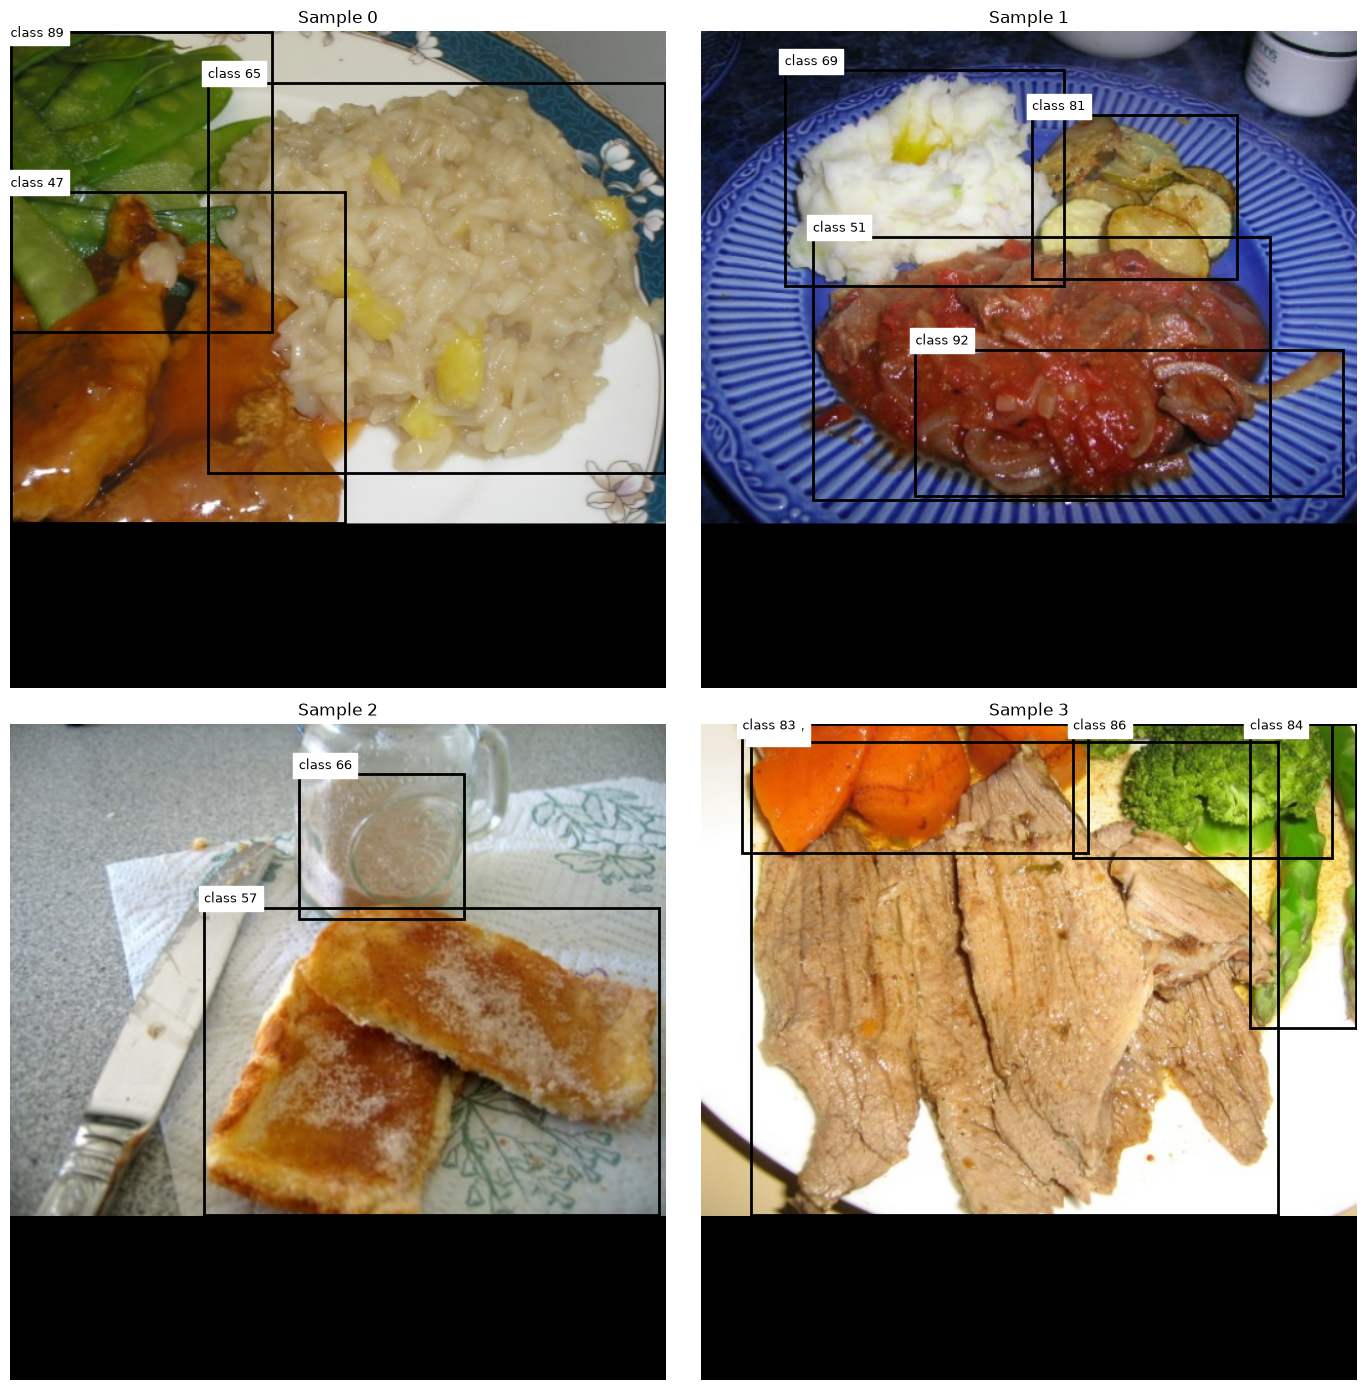

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Use the batch we just created
num_images = images.shape[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for i in range(num_images):
    ax = axes[i]

    # Convert image to uint8 for display
    img = images[i].numpy().astype(np.uint8)

    ax.imshow(img)

    boxes_i = bboxes["boxes"][i].numpy()
    classes_i = bboxes["classes"][i].numpy()

    # Only draw real boxes; padded boxes use -1
    valid = classes_i >= 0

    for box, cls in zip(boxes_i[valid], classes_i[valid]):
        x1, y1, x2, y2 = box

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(y1 - 5, 5),
            f"class {int(cls)}",
            fontsize=9,
            backgroundcolor="white",
        )

    ax.set_title(f"Sample {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from src.detection.model import build_yolov8_detector

print("Building YOLOv8-S detector...")

detector = build_yolov8_detector(
    num_classes=103,
    learning_rate=1e-3,
    box_loss_weight=7.5,
    classification_loss_weight=2.0,
    backbone_trainable=True,
)

print("\n✅ Model built and compiled successfully")

print("\nModel type:")
print(type(detector))

print("\nNumber of classes:")
print(detector.num_classes)

print("\nBounding-box format:")
print(detector.bounding_box_format)

print("\nBackbone:")
print(type(detector.backbone))

print("\nBackbone trainable:")
print(detector.backbone.trainable)

Building YOLOv8-S detector...

✅ Model built and compiled successfully

Model type:
<class 'keras_cv.src.models.object_detection.yolo_v8.yolo_v8_detector.YOLOV8Detector'>

Number of classes:
103

Bounding-box format:
xyxy

Backbone:
<class 'keras_cv.src.models.object_detection.yolo_v8.yolo_v8_backbone.YOLOV8Backbone'>

Backbone trainable:
True


In [14]:
print("Running one forward pass...")

# Use the real batch produced by dataset.py
predictions = detector(images, training=False)

print("✅ Forward pass completed successfully")

print("\nPrediction type:")
print(type(predictions))

if isinstance(predictions, dict):
    print("\nPrediction keys:")
    for key, value in predictions.items():
        print(f"{key}: shape={value.shape}, dtype={value.dtype}")
else:
    print("\nPrediction shape:")
    print(predictions.shape)

Running one forward pass...
✅ Forward pass completed successfully

Prediction type:
<class 'dict'>

Prediction keys:
boxes: shape=(4, 8400, 64), dtype=<dtype: 'float32'>
classes: shape=(4, 8400, 103), dtype=<dtype: 'float32'>
